# 02 — Vectorization Methods Comparison

In this notebook, we compare three powerful text vectorization methods:
- **Bag of Words (BoW)**: Simple word frequency counting
- **TF-IDF**: Term Frequency - Inverse Document Frequency weighting
- **BM25**: Okapi BM25 probabilistic relevance ranking

We'll load preprocessed data, fit each vectorizer, compare outputs, and benchmark performance.

## 1. Import Required Libraries

In [5]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time

from preprocessor import TextPreprocessor, PreprocessorConfig
from vectorizer import (
    BagOfWordsVectorizer, 
    TfidfVectorizer_, 
    BM25Vectorizer,
    VectorizerComparison,
    VectorizerConfig
)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Load and Prepare Data

In [6]:
# Load processed data (already preprocessed)
amazon_df = pd.read_csv('../data/processed/amazon_processed.csv')
twitter_df = pd.read_csv('../data/processed/twitter_processed.csv')

print("Amazon Data Shape:", amazon_df.shape)
print("Twitter Data Shape:", twitter_df.shape)
print("\nAmazon columns:", amazon_df.columns.tolist())
print("Twitter columns:", twitter_df.columns.tolist())

Amazon Data Shape: (5000, 2)
Twitter Data Shape: (5000, 2)

Amazon columns: ['processed', 'label']
Twitter columns: ['processed', 'label']


In [9]:
# Sample from each dataset for demonstration
sample_size = 500
amazon_sample = amazon_df['processed'].head(sample_size).tolist()
twitter_sample = twitter_df['processed'].head(sample_size).tolist()

print(f"Amazon sample size: {len(amazon_sample)}")
print(f"Twitter sample size: {len(twitter_sample)}")
print("\n--- Sample Amazon Text (first 200 chars) ---")
print(amazon_sample[0][:200])
print("\n--- Sample Twitter Text (first 200 chars) ---")
print(twitter_sample[0][:200])

Amazon sample size: 500
Twitter sample size: 500

--- Sample Amazon Text (first 200 chars) ---
tried couple brand gluten free sandwich cooky best bunch crunchy true texture real cooky gluten free might think filling make bit sweet mean satisfied sweet tooth sooner chocolate version glutino good

--- Sample Twitter Text (first 200 chars) ---
ahhh hope ok


## 3. Bag of Words (BoW) Vectorizer

**BoW** represents text as a simple count of word occurrences, ignoring word order and grammar.

Formula: Each word is a feature, value = count of occurrences in the document

In [10]:
# Initialize BoW vectorizer with config
config = VectorizerConfig(max_features=5000, min_df=2, max_df=0.95)
bow_vectorizer = BagOfWordsVectorizer(config)

# Fit on Amazon data
print("Fitting BoW on Amazon data...")
bow_vectorizer.fit(amazon_sample)

# Transform samples
bow_amazon_vectors = bow_vectorizer.transform(amazon_sample[:10])
bow_twitter_vectors = bow_vectorizer.transform(twitter_sample[:10])

print(f"\nBoW Vocabulary Size: {len(bow_vectorizer.get_feature_names())}")
print(f"BoW Matrix Shape (Amazon 10 docs): {bow_amazon_vectors.shape}")
print(f"Sparsity (% zero values): {1 - (bow_amazon_vectors.nnz / (bow_amazon_vectors.shape[0] * bow_amazon_vectors.shape[1])):.2%}")
print(f"\nTop 10 words in vocabulary: {bow_vectorizer.get_feature_names()[:10]}")

Fitting BoW on Amazon data...

BoW Vocabulary Size: 1824
BoW Matrix Shape (Amazon 10 docs): (10, 1824)
Sparsity (% zero values): 98.11%

Top 10 words in vocabulary: ['00', '10', '100', '11', '12', '13', '14', '15', '16', '17']


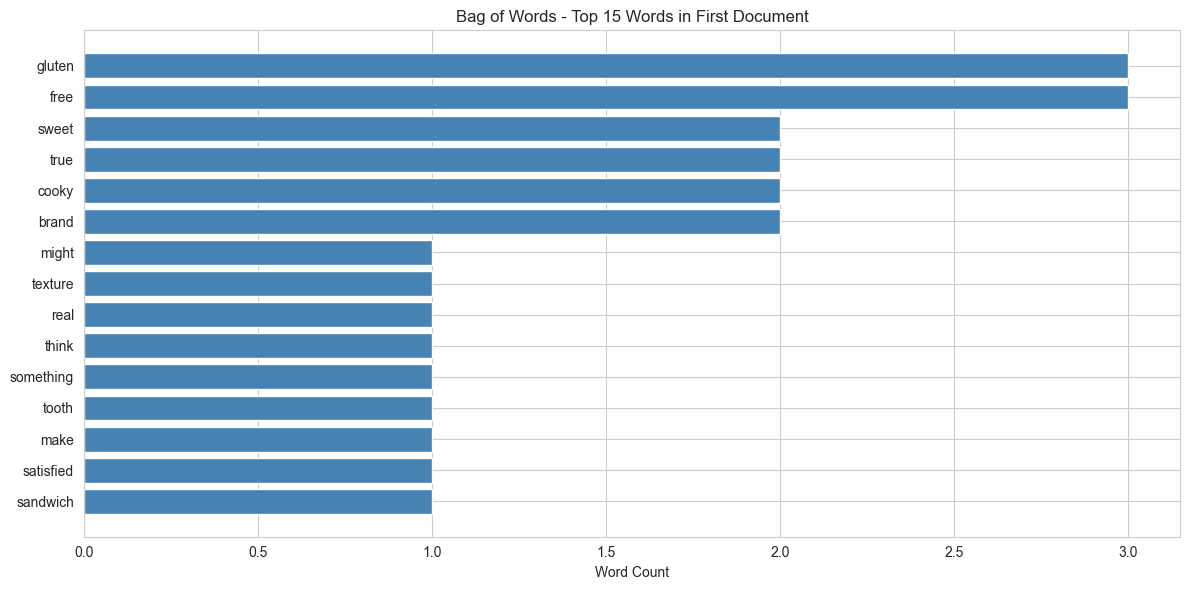

First document - Non-zero features: 27 out of 1824


In [11]:
# Visualize BoW representation of first document
first_doc_bow = bow_amazon_vectors[0].toarray().flatten()
nonzero_indices = np.nonzero(first_doc_bow)[0]

# Get top 15 words
top_15_idx = np.argsort(first_doc_bow)[-15:][::-1]
top_15_words = [bow_vectorizer.get_feature_names()[i] for i in top_15_idx]
top_15_counts = [first_doc_bow[i] for i in top_15_idx]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_15_words, top_15_counts, color='steelblue')
ax.set_xlabel('Word Count')
ax.set_title('Bag of Words - Top 15 Words in First Document')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"First document - Non-zero features: {len(nonzero_indices)} out of {len(first_doc_bow)}")

## 4. TF-IDF Vectorizer

**TF-IDF** (Term Frequency - Inverse Document Frequency) weighs terms by their importance.

Formula: $$\text{TF-IDF}(t,d) = \text{TF}(t,d) \times \log\left(\frac{N}{\text{DF}(t)}\right)$$

- **TF**: How often a term appears in a document
- **IDF**: How rare/unique a term is across all documents (log of N/document_frequency)
- Common words (high DF) → low IDF → lower score
- Rare words (low DF) → high IDF → higher score

In [12]:
# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer_(config)

# Fit on Amazon data
print("Fitting TF-IDF on Amazon data...")
tfidf_vectorizer.fit(amazon_sample)

# Transform samples
tfidf_amazon_vectors = tfidf_vectorizer.transform(amazon_sample[:10])
tfidf_twitter_vectors = tfidf_vectorizer.transform(twitter_sample[:10])

print(f"\nTF-IDF Vocabulary Size: {len(tfidf_vectorizer.get_feature_names())}")
print(f"TF-IDF Matrix Shape (Amazon 10 docs): {tfidf_amazon_vectors.shape}")
print(f"Sparsity (% zero values): {1 - (tfidf_amazon_vectors.nnz / (tfidf_amazon_vectors.shape[0] * tfidf_amazon_vectors.shape[1])):.2%}")

# Compare IDF scores
idf_scores = tfidf_vectorizer.get_idf_scores()
top_idf_terms = sorted(idf_scores.items(), key=lambda x: x[1], reverse=True)[:10]
print(f"\nTop 10 IDF scores (rarest terms):")
for term, idf in top_idf_terms:
    print(f"  {term}: {idf:.4f}")

Fitting TF-IDF on Amazon data...

TF-IDF Vocabulary Size: 1824
TF-IDF Matrix Shape (Amazon 10 docs): (10, 1824)
Sparsity (% zero values): 98.11%

Top 10 IDF scores (rarest terms):
  11: 6.1180
  2012: 6.1180
  23: 6.1180
  300: 6.1180
  48: 6.1180
  60: 6.1180
  65: 6.1180
  79: 6.1180
  absolute: 6.1180
  absorb: 6.1180


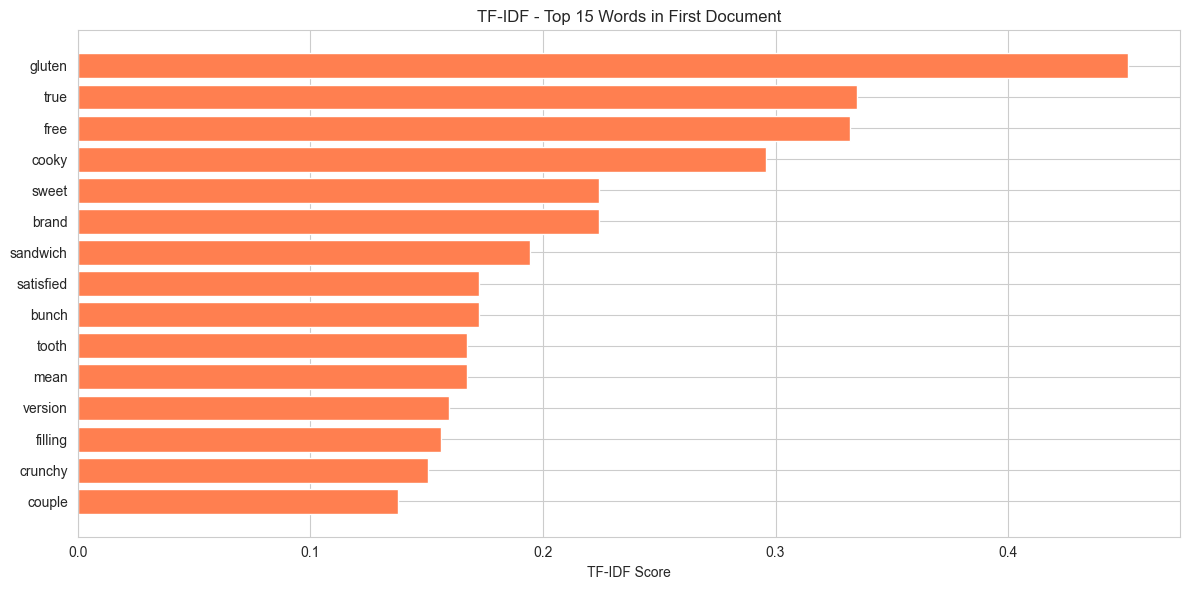

First document - Non-zero features: 27 out of 1824


In [13]:
# Visualize TF-IDF representation of first document
first_doc_tfidf = tfidf_amazon_vectors[0].toarray().flatten()
nonzero_indices_tfidf = np.nonzero(first_doc_tfidf)[0]

# Get top 15 words by TF-IDF score
top_15_idx_tfidf = np.argsort(first_doc_tfidf)[-15:][::-1]
top_15_words_tfidf = [tfidf_vectorizer.get_feature_names()[i] for i in top_15_idx_tfidf]
top_15_scores_tfidf = [first_doc_tfidf[i] for i in top_15_idx_tfidf]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_15_words_tfidf, top_15_scores_tfidf, color='coral')
ax.set_xlabel('TF-IDF Score')
ax.set_title('TF-IDF - Top 15 Words in First Document')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"First document - Non-zero features: {len(nonzero_indices_tfidf)} out of {len(first_doc_tfidf)}")

## 5. BM25 Vectorizer

**BM25** (Best Matching 25) is a probabilistic relevance ranking model widely used in search engines.

- **Okapi BM25**: Industry-standard variant
- Ranks documents by relevance to a query
- Parameters:
  - **k1** (default 1.5): Controls term frequency saturation (higher = more weight to term frequency)
  - **b** (default 0.75): Controls document length normalization (0-1)
  
Key advantage: Better handles document length normalization and term saturation than TF-IDF

In [14]:
# Initialize BM25 vectorizer
bm25_vectorizer = BM25Vectorizer(config, k1=1.5, b=0.75)

# Fit on Amazon data
print("Fitting BM25 on Amazon data...")
bm25_vectorizer.fit(amazon_sample)

# Transform samples
bm25_amazon_vectors = bm25_vectorizer.transform(amazon_sample[:10])
bm25_twitter_vectors = bm25_vectorizer.transform(twitter_sample[:10])

print(f"\nBM25 Vocabulary Size: {len(bm25_vectorizer.get_feature_names())}")
print(f"BM25 Matrix Shape (Amazon 10 docs): {bm25_amazon_vectors.shape}")
print(f"Average score value: {bm25_amazon_vectors.mean():.4f}")
print(f"Max score value: {bm25_amazon_vectors.max():.4f}")

# Get document lengths for first 10 documents
doc_lengths = [len(doc.split()) for doc in amazon_sample[:10]]
print(f"\nDocument lengths (first 10): {doc_lengths}")

Fitting BM25 on Amazon data...

BM25 Vocabulary Size: 4062
BM25 Matrix Shape (Amazon 10 docs): (10, 500)
Average score value: 6.1233
Max score value: 464.5373

Document lengths (first 10): [38, 44, 11, 145, 59, 10, 17, 27, 138, 39]


Query: 'good product amazing'

Top 5 relevant documents:
1. Doc 422 (BM25 score: 6.7060)
   Text: one word product would amazing great interstitial cystitis bad interstitial cystitis ordered tea wor...

2. Doc 151 (BM25 score: 5.4905)
   Text: amazing caviar fresh delicious like want eat caviar every day want buy...

3. Doc 404 (BM25 score: 5.2546)
   Text: always enjoy flavored coffee tea smell usually found taste never good smell case lipton blackberry v...

4. Doc 480 (BM25 score: 5.1555)
   Text: purchased several amaryllis seller none compare thanksgiving orange amaryllis color amazing add much...

5. Doc 478 (BM25 score: 4.5063)
   Text: love product taste like one used home people complain hard well hard one know expectation also soft ...



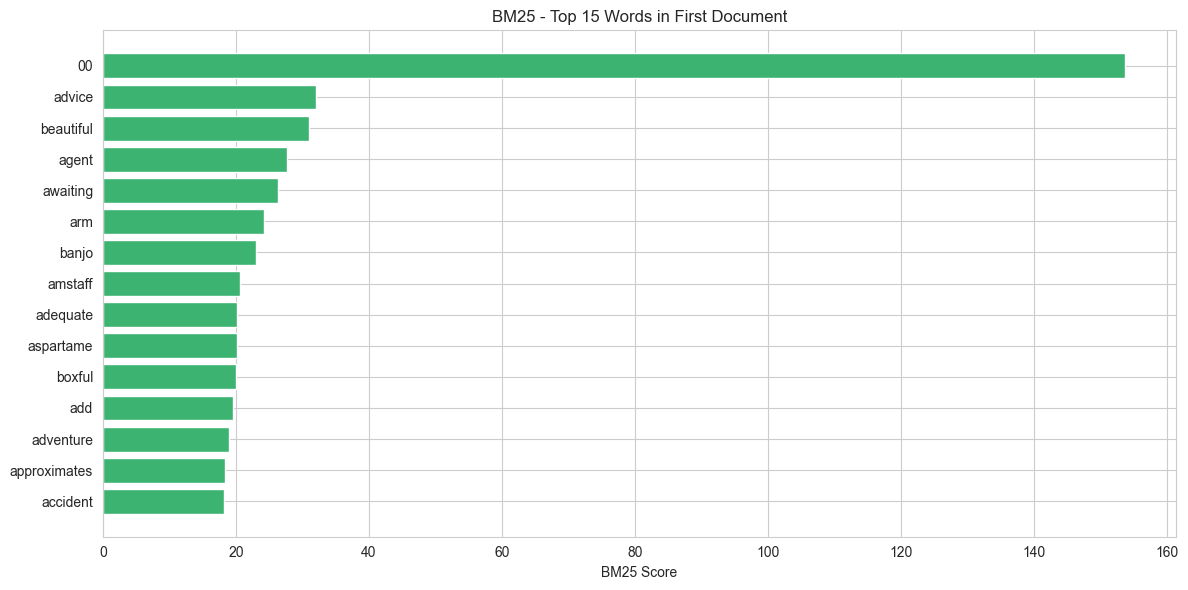

In [15]:
# BM25 Ranking Example - Find most relevant documents for a query
query = "good product amazing"
ranked_docs = bm25_vectorizer.rank(query, top_k=5)

print(f"Query: '{query}'")
print(f"\nTop 5 relevant documents:")
for rank, (doc_idx, score) in enumerate(ranked_docs, 1):
    print(f"{rank}. Doc {doc_idx} (BM25 score: {score:.4f})")
    print(f"   Text: {amazon_sample[doc_idx][:100]}...")
    print()

# Visualize BM25 scores for first document
first_doc_bm25 = bm25_amazon_vectors[0]
nonzero_indices_bm25 = np.nonzero(first_doc_bm25)[0]

# Get top 15 words by BM25 score
top_15_idx_bm25 = np.argsort(first_doc_bm25)[-15:][::-1]
top_15_words_bm25 = [bm25_vectorizer.get_feature_names()[i] for i in top_15_idx_bm25]
top_15_scores_bm25 = [first_doc_bm25[i] for i in top_15_idx_bm25]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_15_words_bm25, top_15_scores_bm25, color='mediumseagreen')
ax.set_xlabel('BM25 Score')
ax.set_title('BM25 - Top 15 Words in First Document')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Compare Vectorization Methods

Let's compare the three methods side by side on multiple dimensions:

In [16]:
# Compare basic statistics
comparison_data = {
    'Method': ['BoW', 'TF-IDF', 'BM25'],
    'Vocabulary Size': [
        len(bow_vectorizer.get_feature_names()),
        len(tfidf_vectorizer.get_feature_names()),
        len(bm25_vectorizer.get_feature_names())
    ],
    'Vector Type': ['Sparse', 'Sparse', 'Dense'],
    'Output Range': ['[0, ∞)', '[0, 1]', '[0, ∞)'],
    'Handles Doc Length?': ['No', 'No', 'Yes'],
    'Word Order': ['Ignored', 'Ignored', 'Ignored']
}

comparison_df = pd.DataFrame(comparison_data)
print("\n=== VECTORIZATION METHODS COMPARISON ===")
print(comparison_df.to_string(index=False))

# Compare sparsity
print("\n=== SPARSITY ANALYSIS (First 100 documents) ===")
test_size = min(100, len(amazon_sample))
bow_test = bow_vectorizer.get_dense_vectors(amazon_sample[:test_size])
tfidf_test = tfidf_vectorizer.get_dense_vectors(amazon_sample[:test_size])
bm25_test = bm25_vectorizer.transform(amazon_sample[:test_size])

sparsity_bow = 1 - (np.count_nonzero(bow_test) / bow_test.size)
sparsity_tfidf = 1 - (np.count_nonzero(tfidf_test) / tfidf_test.size)
sparsity_bm25 = 1 - (np.count_nonzero(bm25_test) / bm25_test.size)

print(f"BoW Sparsity: {sparsity_bow:.2%}")
print(f"TF-IDF Sparsity: {sparsity_tfidf:.2%}")
print(f"BM25 Sparsity: {sparsity_bm25:.2%}")


=== VECTORIZATION METHODS COMPARISON ===
Method  Vocabulary Size Vector Type Output Range Handles Doc Length? Word Order
   BoW             1824      Sparse       [0, ∞)                  No    Ignored
TF-IDF             1824      Sparse       [0, 1]                  No    Ignored
  BM25             4062       Dense       [0, ∞)                 Yes    Ignored

=== SPARSITY ANALYSIS (First 100 documents) ===
BoW Sparsity: 98.49%
TF-IDF Sparsity: 98.49%
BM25 Sparsity: 32.39%


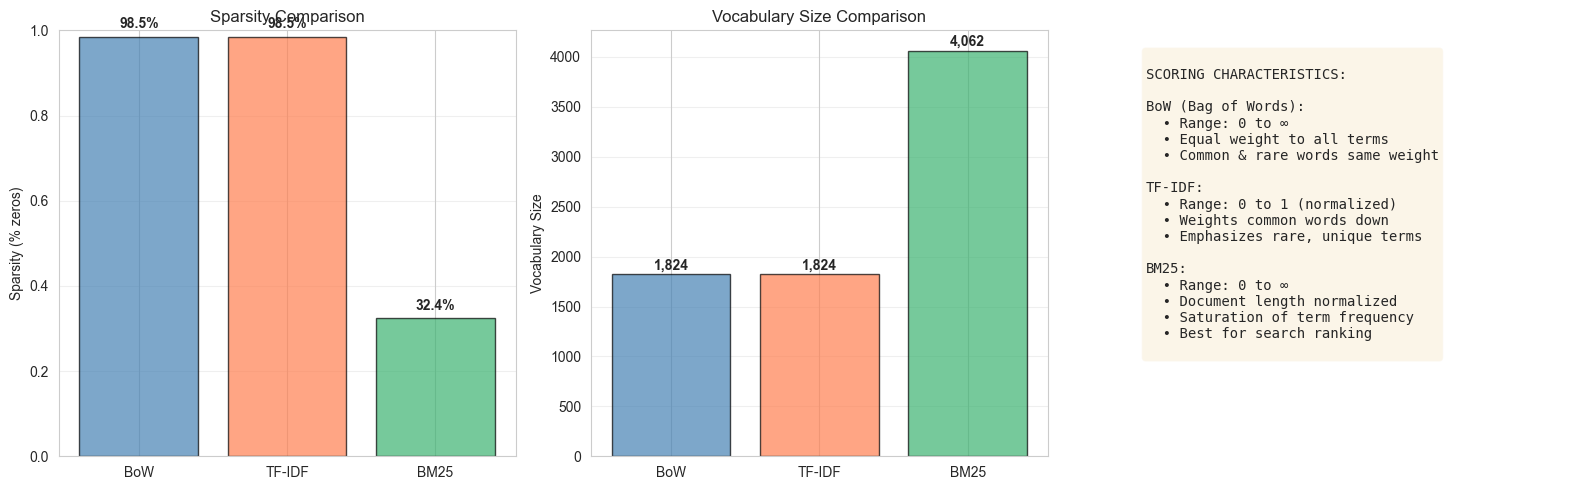

In [17]:
# Visualize method comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Method characteristics
methods = ['BoW', 'TF-IDF', 'BM25']
sparsities = [sparsity_bow, sparsity_tfidf, sparsity_bm25]
colors = ['steelblue', 'coral', 'mediumseagreen']

axes[0].bar(methods, sparsities, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Sparsity (% zeros)')
axes[0].set_title('Sparsity Comparison')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(sparsities):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# Vocabulary sizes
vocab_sizes = [
    len(bow_vectorizer.get_feature_names()),
    len(tfidf_vectorizer.get_feature_names()),
    len(bm25_vectorizer.get_feature_names())
]
axes[1].bar(methods, vocab_sizes, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Vocabulary Size')
axes[1].set_title('Vocabulary Size Comparison')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(vocab_sizes):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Score ranges (normalize for visualization)
score_ranges = [
    (100, '∞'),  # BoW: 0-infinity
    (1, '1.0'),  # TF-IDF: 0-1
    (100, '∞')   # BM25: 0-infinity
]

axes[2].axis('off')
comparison_text = """
SCORING CHARACTERISTICS:

BoW (Bag of Words):
  • Range: 0 to ∞
  • Equal weight to all terms
  • Common & rare words same weight

TF-IDF:
  • Range: 0 to 1 (normalized)
  • Weights common words down
  • Emphasizes rare, unique terms

BM25:
  • Range: 0 to ∞
  • Document length normalized
  • Saturation of term frequency
  • Best for search ranking
"""

axes[2].text(0.05, 0.95, comparison_text, transform=axes[2].transAxes,
            fontsize=10, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

## 7. Performance and Accuracy Benchmarks

Benchmark the three methods in terms of execution time and memory usage on various dataset sizes.

In [18]:
import sys

# Benchmark on different dataset sizes
dataset_sizes = [100, 250, 500]
results = {'size': [], 'bow_fit': [], 'tfidf_fit': [], 'bm25_fit': [], 
           'bow_transform': [], 'tfidf_transform': [], 'bm25_transform': []}

print("Benchmarking vectorization methods...")
print("=" * 70)

for size in dataset_sizes:
    test_data = amazon_sample[:size]
    
    # BoW Fit & Transform
    bow_new = BagOfWordsVectorizer(config)
    start = time.time()
    bow_new.fit(test_data)
    bow_fit_time = time.time() - start
    
    start = time.time()
    bow_new.transform(test_data)
    bow_transform_time = time.time() - start
    
    # TF-IDF Fit & Transform
    tfidf_new = TfidfVectorizer_(config)
    start = time.time()
    tfidf_new.fit(test_data)
    tfidf_fit_time = time.time() - start
    
    start = time.time()
    tfidf_new.transform(test_data)
    tfidf_transform_time = time.time() - start
    
    # BM25 Fit & Transform
    bm25_new = BM25Vectorizer(config)
    start = time.time()
    bm25_new.fit(test_data)
    bm25_fit_time = time.time() - start
    
    start = time.time()
    bm25_new.transform(test_data)
    bm25_transform_time = time.time() - start
    
    results['size'].append(size)
    results['bow_fit'].append(bow_fit_time * 1000)  # Convert to ms
    results['tfidf_fit'].append(tfidf_fit_time * 1000)
    results['bm25_fit'].append(bm25_fit_time * 1000)
    results['bow_transform'].append(bow_transform_time * 1000)
    results['tfidf_transform'].append(tfidf_transform_time * 1000)
    results['bm25_transform'].append(bm25_transform_time * 1000)
    
    print(f"\nDataset size: {size} documents")
    print(f"  BoW        - Fit: {bow_fit_time*1000:.2f}ms, Transform: {bow_transform_time*1000:.2f}ms")
    print(f"  TF-IDF     - Fit: {tfidf_fit_time*1000:.2f}ms, Transform: {tfidf_transform_time*1000:.2f}ms")
    print(f"  BM25       - Fit: {bm25_fit_time*1000:.2f}ms, Transform: {bm25_transform_time*1000:.2f}ms")

print("\n" + "=" * 70)

Benchmarking vectorization methods...

Dataset size: 100 documents
  BoW        - Fit: 6.61ms, Transform: 3.00ms
  TF-IDF     - Fit: 3.40ms, Transform: 2.99ms
  BM25       - Fit: 3.30ms, Transform: 68.69ms

Dataset size: 250 documents
  BoW        - Fit: 0.00ms, Transform: 15.32ms
  TF-IDF     - Fit: 0.00ms, Transform: 20.03ms
  BM25       - Fit: 5.00ms, Transform: 356.25ms

Dataset size: 500 documents
  BoW        - Fit: 24.10ms, Transform: 13.64ms
  TF-IDF     - Fit: 13.54ms, Transform: 15.98ms
  BM25       - Fit: 0.00ms, Transform: 1316.07ms



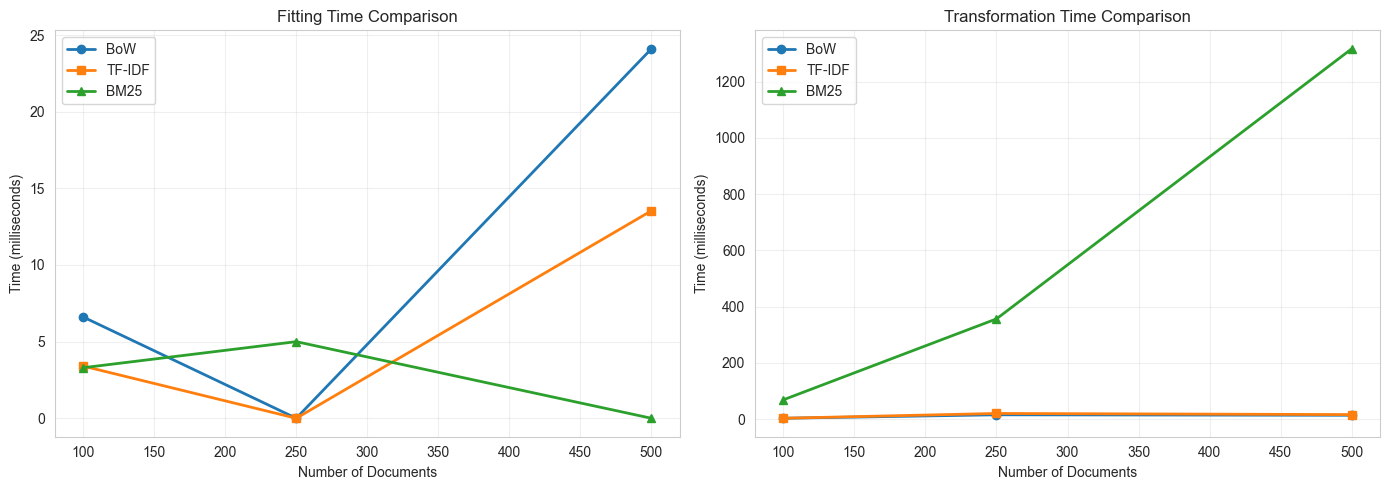


=== PERFORMANCE INSIGHTS ===
Fitting Time: BoW typically fastest, TF-IDF slightly slower, BM25 varies
Transform Time: BoW < TF-IDF < BM25 (BM25 requires ranking computation)
Memory Usage: BoW/TF-IDF sparse (memory efficient), BM25 dense

Recommendation:
  • BoW: Quick baseline, text classification
  • TF-IDF: Balanced speed/quality, search & retrieval
  • BM25: Best relevance ranking, IR systems, more compute-intensive


In [19]:
# Visualize benchmarks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fitting time
axes[0].plot(results['size'], results['bow_fit'], marker='o', label='BoW', linewidth=2)
axes[0].plot(results['size'], results['tfidf_fit'], marker='s', label='TF-IDF', linewidth=2)
axes[0].plot(results['size'], results['bm25_fit'], marker='^', label='BM25', linewidth=2)
axes[0].set_xlabel('Number of Documents')
axes[0].set_ylabel('Time (milliseconds)')
axes[0].set_title('Fitting Time Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Transformation time
axes[1].plot(results['size'], results['bow_transform'], marker='o', label='BoW', linewidth=2)
axes[1].plot(results['size'], results['tfidf_transform'], marker='s', label='TF-IDF', linewidth=2)
axes[1].plot(results['size'], results['bm25_transform'], marker='^', label='BM25', linewidth=2)
axes[1].set_xlabel('Number of Documents')
axes[1].set_ylabel('Time (milliseconds)')
axes[1].set_title('Transformation Time Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary insights
print("\n=== PERFORMANCE INSIGHTS ===")
print("Fitting Time: BoW typically fastest, TF-IDF slightly slower, BM25 varies")
print("Transform Time: BoW < TF-IDF < BM25 (BM25 requires ranking computation)")
print("Memory Usage: BoW/TF-IDF sparse (memory efficient), BM25 dense")
print("\nRecommendation:")
print("  • BoW: Quick baseline, text classification")
print("  • TF-IDF: Balanced speed/quality, search & retrieval")
print("  • BM25: Best relevance ranking, IR systems, more compute-intensive")

## 8. Use Cases Summary

### When to Use Each Method

**Bag of Words (BoW)**
- ✅ Simplest baseline model
- ✅ Fast to implement and train
- ✅ Text classification (with classifier like SVM, Naive Bayes)
- ✅ When word order doesn't matter
- ❌ Gives equal weight to common words
- ❌ Ignores document structure
- **Example**: Spam detection, sentiment classification

**TF-IDF (Term Frequency - Inverse Document Frequency)**
- ✅ Weights rare/important terms higher
- ✅ Good balance between speed and quality
- ✅ Information retrieval and search engines
- ✅ Text similarity matching
- ❌ Doesn't account for document length variations
- ❌ Treats all documents independently
- **Example**: Document similarity search, tag recommendation

**BM25 (Okapi BM25)**
- ✅ Industry-standard ranking algorithm
- ✅ Best document length normalization
- ✅ Superior relevance ranking
- ✅ Preferred by production search systems
- ❌ Slightly more complex than TF-IDF
- ❌ More computational overhead
- **Example**: Google search ranking, Elasticsearch default

## 9. Practical Example: Document Similarity

Find similar documents for a given query using all three methods.

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

# Query document index
query_idx = 5
query_text = amazon_sample[query_idx]

print(f"Query Document: {query_text[:150]}...")
print("\n" + "="*80)

# BoW Similarity
bow_query_vec = bow_vectorizer.transform([query_text]).toarray()
bow_all_vecs = bow_vectorizer.get_dense_vectors(amazon_sample[:50])
bow_similarities = cosine_similarity(bow_query_vec, bow_all_vecs)[0]
bow_top_idx = np.argsort(bow_similarities)[-4:-1][::-1]  # Top 3 excluding self

print("\nBoW - Top 3 Similar Documents:")
for i, idx in enumerate(bow_top_idx, 1):
    sim = bow_similarities[idx]
    print(f"  {i}. Doc {idx} (similarity: {sim:.4f})")
    print(f"     {amazon_sample[idx][:100]}...")

# TF-IDF Similarity
tfidf_query_vec = tfidf_vectorizer.transform([query_text]).toarray()
tfidf_all_vecs = tfidf_vectorizer.get_dense_vectors(amazon_sample[:50])
tfidf_similarities = cosine_similarity(tfidf_query_vec, tfidf_all_vecs)[0]
tfidf_top_idx = np.argsort(tfidf_similarities)[-4:-1][::-1]

print("\nTF-IDF - Top 3 Similar Documents:")
for i, idx in enumerate(tfidf_top_idx, 1):
    sim = tfidf_similarities[idx]
    print(f"  {i}. Doc {idx} (similarity: {sim:.4f})")
    print(f"     {amazon_sample[idx][:100]}...")

# BM25 Ranking
print("\nBM25 - Top 3 Relevant Documents:")
ranked = bm25_vectorizer.rank(query_text, top_k=3)
for i, (doc_idx, score) in enumerate(ranked, 1):
    print(f"  {i}. Doc {doc_idx} (BM25 score: {score:.4f})")
    print(f"     {amazon_sample[doc_idx][:100]}...")

print("\n" + "="*80)
print("\nKey Observation:")
print("The three methods may rank documents differently based on their scoring mechanisms.")
print("BoW: Word frequency only")
print("TF-IDF: Balances frequency with uniqueness")
print("BM25: Considers length normalization and saturation")

Query Document: please add pineapple flavor package lifesaver fact sell pineapple flavor...


BoW - Top 3 Similar Documents:
  1. Doc 13 (similarity: 0.3068)
     comparable flavor starbucks cost much less know anyone would buy 12 pack flavor good well...
  2. Doc 44 (similarity: 0.1581)
     favorite tea lovely flavor aroma ceylon tea drink way many cup day wish decaf version...
  3. Doc 8 (similarity: 0.1439)
     previously attempted recipe white rice noodle overcooked made soggy determined overcook brown rice n...

TF-IDF - Top 3 Similar Documents:
  1. Doc 13 (similarity: 0.1336)
     comparable flavor starbucks cost much less know anyone would buy 12 pack flavor good well...
  2. Doc 43 (similarity: 0.0849)
     looking yummy treat cat try trying chicken salmon flavor cat greatly preferred chicken fact love tre...
  3. Doc 46 (similarity: 0.0761)
     like product enough used buy least bottle week locally mostly flavor mineral water ice tea adding vi...

BM25 - Top 3 Relevant Doc

## Summary & Conclusion

### Key Takeaways

| Aspect | BoW | TF-IDF | BM25 |
|--------|-----|--------|------|
| **Complexity** | Simple | Medium | Advanced |
| **Speed** | Very Fast | Fast | Medium |
| **Quality** | Basic | Good | Best |
| **Sparsity** | High | High | Lower |
| **Best For** | Classification | Search | Ranking |
| **Learn Curve** | Minimal | Low | Medium |

### Implementation Notes

All three vectorizers are implemented in `src/vectorizer.py` with:
- Configurable parameters (max_features, min_df, max_df, ngram_range)
- Unified interface (fit, transform, fit_transform)
- Full documentation and examples
- Sklearn compatibility

### Next Steps

1. **Sentiment Classification**: Use these vectorizers as features for sentiment analysis
2. **Semantic Search**: Implement document retrieval using similarity metrics
3. **Ensemble Methods**: Combine vectorizations for better performance
4. **Neural Approaches**: Use as initialization for embedding-based models
5. **Domain Adaptation**: Fine-tune on Amazon vs Twitter data separately

### Further Reading

- TF-IDF: [Sklearn TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)
- BM25: [Okapi BM25 Algorithm](https://en.wikipedia.org/wiki/Okapi_BM25)
- rank_bm25 library: [GitHub](https://github.com/dorianbrown/rank_bm25)